# 🏠 California Housing Price — Exploratory Data Analysis

> **Project:** California Housing Price Predictor  
> **Model:** Tuned RandomForest — CV RMSE: $48,713 | R²: 0.9749  
> **Dataset:** California Census 1990 — [Kaggle Source](https://www.kaggle.com/datasets/camnugent/california-housing-prices)  
> **Author:** Abu Shadab Khan

---

## 📋 Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Dataset Overview](#2-overview)
3. [Missing Value Analysis](#3-missing)
4. [Target Variable Distribution](#4-target)
5. [Feature Distributions](#5-features)
6. [Correlation Analysis](#6-correlation)
7. [Geographical Visualization](#7-geo)
8. [Ocean Proximity Analysis](#8-ocean)
9. [Feature Engineering Insights](#9-engineering)
10. [Key Findings Summary](#10-summary)

## 1. Setup & Data Loading <a id='1-setup'></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f9f9f9',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
})

PALETTE  = 'viridis'
ACCENT   = '#2196F3'
ORANGE   = '#FF7043'
GREEN    = '#43A047'

# ── Load data ─────────────────────────────────────────────
df = pd.read_csv('housing.csv')
print(f' Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

 Dataset loaded: 20,640 rows × 10 columns


## 2. Dataset Overview <a id='2-overview'></a>

In [3]:
print('── First 5 rows ──')
df.head()

── First 5 rows ──


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
print('── Data Types & Non-null Counts ──')
df.info()

── Data Types & Non-null Counts ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
print('── Statistical Summary ──')
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','50%','max'])

── Statistical Summary ──


,count,mean,std,min,25%,50%,75%,max
longitude,20640.000000,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
latitude,20640.000000,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
housing_median_age,20640.000000,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
total_rooms,20640.000000,2635.763081,2181.615252,2.000000,1447.750000,2127.000000,3148.000000,39320.000000
total_bedrooms,20433.000000,537.870553,421.385070,1.000000,296.000000,435.000000,647.000000,6445.000000
population,20640.000000,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
households,20640.000000,499.539680,382.329753,1.000000,280.000000,409.000000,605.000000,6082.000000
median_income,20640.000000,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
median_house_value,20640.000000,206855.816909,115395.615874,14999.000000,119600.000000,179700.000000,264725.000000,500001.000000


## 3. Missing Value Analysis <a id='3-missing'></a>

── Missing Values ──
                Missing Count  Missing %
total_bedrooms            207        1.0


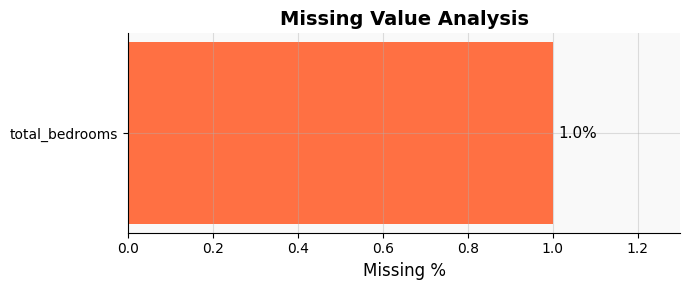


 Fix: SimpleImputer(strategy="median") used in pipeline — median is robust to outliers.


In [6]:
if not os.path.exists('plots'):
    os.makedirs('plots')

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('── Missing Values ──')
print(missing_df)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color=ORANGE, height=0.4)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11)
ax.set_xlabel('Missing %')
ax.set_title('Missing Value Analysis')
ax.set_xlim(0, missing_df['Missing %'].max() * 1.3)
plt.tight_layout()
plt.savefig('plots/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Fix: SimpleImputer(strategy="median") used in pipeline — median is robust to outliers.')

## 4. Target Variable Distribution <a id='4-target'></a>

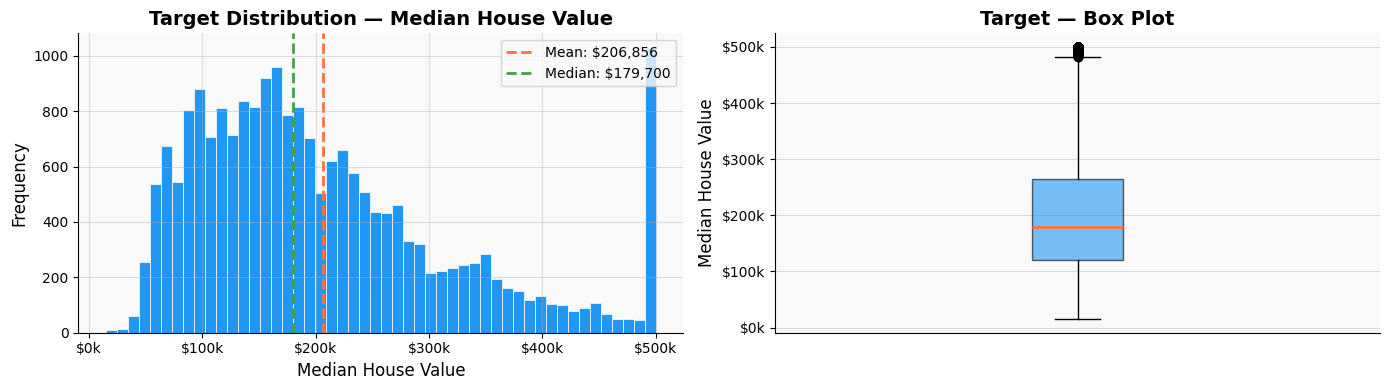


📊 Key Stats:
   Mean   : $206,856
   Median : $179,700
   Std    : $115,396
   Max    : $500,001  ← hard cap at $500,001 (data artifact)

💡 The spike at $500,001 is a data cap — houses above this value were clipped in the census.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['median_house_value'], bins=50, color=ACCENT, edgecolor='white', linewidth=0.5)
axes[0].axvline(df['median_house_value'].mean(),   color=ORANGE, linestyle='--', linewidth=2, label=f'Mean: ${df["median_house_value"].mean():,.0f}')
axes[0].axvline(df['median_house_value'].median(), color=GREEN,  linestyle='--', linewidth=2, label=f'Median: ${df["median_house_value"].median():,.0f}')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_title('Target Distribution — Median House Value')
axes[0].set_xlabel('Median House Value')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
axes[1].boxplot(df['median_house_value'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=ACCENT, alpha=0.6),
                medianprops=dict(color=ORANGE, linewidth=2))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_title('Target — Box Plot')
axes[1].set_ylabel('Median House Value')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('plots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Key Stats:')
print(f'   Mean   : ${df["median_house_value"].mean():,.0f}')
print(f'   Median : ${df["median_house_value"].median():,.0f}')
print(f'   Std    : ${df["median_house_value"].std():,.0f}')
print(f'   Max    : ${df["median_house_value"].max():,.0f}  ← hard cap at $500,001 (data artifact)')
print(f'\n💡 The spike at $500,001 is a data cap — houses above this value were clipped in the census.')

## 5. Feature Distributions <a id='5-features'></a>

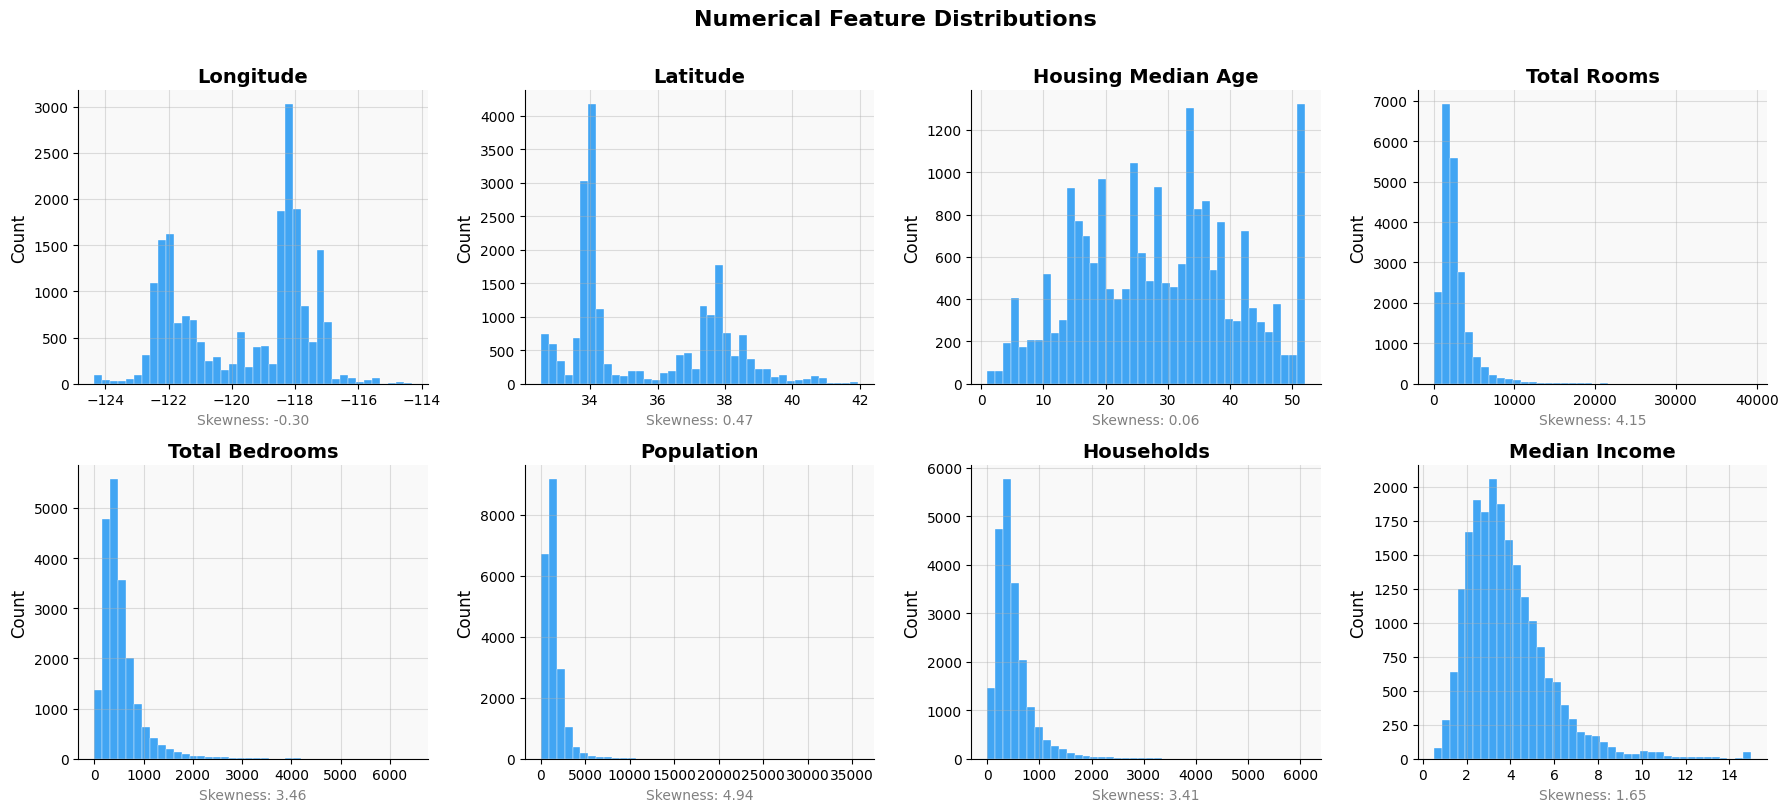

💡 Highly skewed features (total_rooms, total_bedrooms, population) benefit from log transform.
💡 median_income is the most normally distributed — and our strongest predictor.


In [8]:
num_cols = ['longitude','latitude','housing_median_age','total_rooms',
            'total_bedrooms','population','households','median_income']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color=ACCENT, edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_ylabel('Count')
    skew = df[col].skew()
    axes[i].set_xlabel(f'Skewness: {skew:.2f}', fontsize=10, color='gray')

plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Highly skewed features (total_rooms, total_bedrooms, population) benefit from log transform.')
print('💡 median_income is the most normally distributed — and our strongest predictor.')

## 6. Correlation Analysis <a id='6-correlation'></a>

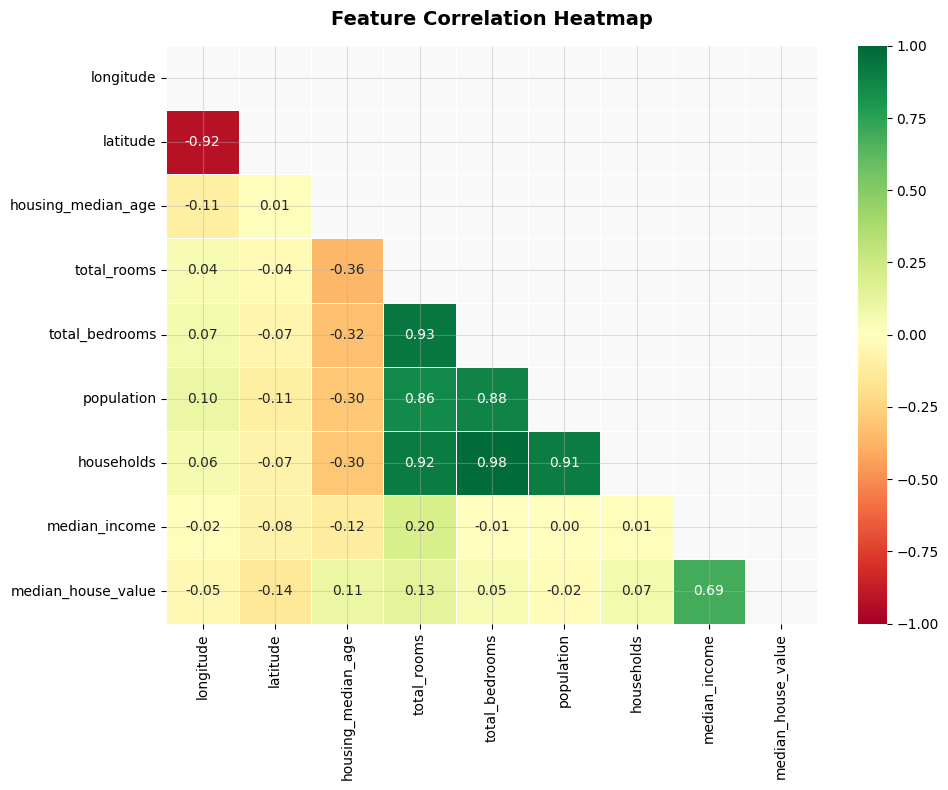

In [9]:
# ── Correlation heatmap ───────────────────────────────────
corr = df[num_cols + ['median_house_value']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 10},
            linewidths=0.5, linecolor='white')
ax.set_title('Feature Correlation Heatmap', pad=15)
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

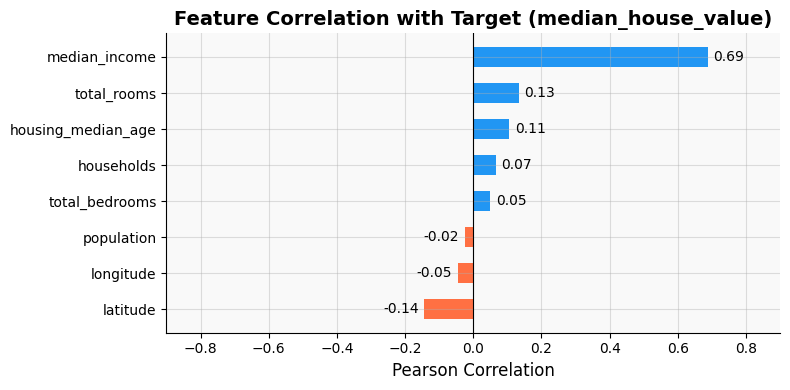


💡 Key insight: median_income has the strongest positive correlation (0.69)
💡 latitude has negative correlation — northern CA houses tend to be cheaper


In [10]:
# ── Correlation with target ───────────────────────────────
target_corr = corr['median_house_value'].drop('median_house_value').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = [ORANGE if v < 0 else ACCENT for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, height=0.55)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-0.9, 0.9)
ax.set_title('Feature Correlation with Target (median_house_value)')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('plots/target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Key insight: median_income has the strongest positive correlation (0.69)')
print('💡 latitude has negative correlation — northern CA houses tend to be cheaper')

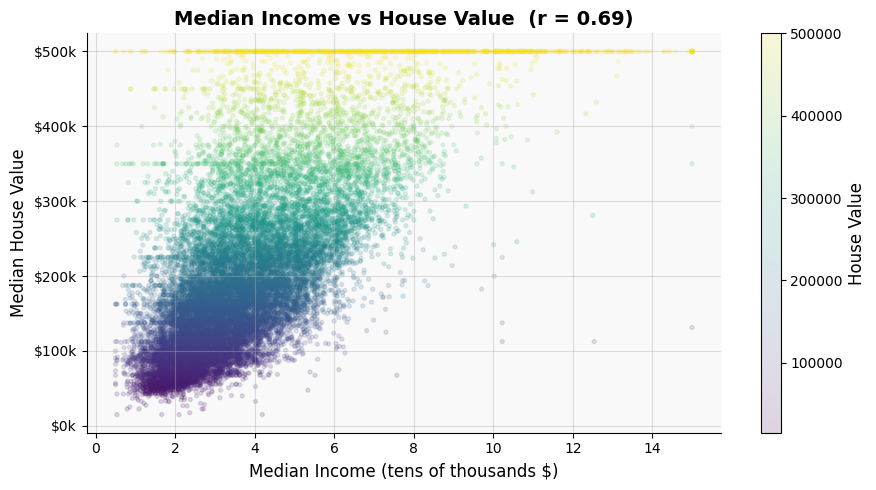

💡 Clear positive trend. Horizontal bands at $500k = data cap artifact.


In [11]:
# ── Scatter: income vs house value ───────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(df['median_income'], df['median_house_value'],
                     alpha=0.15, s=8, c=df['median_house_value'],
                     cmap=PALETTE)
plt.colorbar(scatter, ax=ax, label='House Value')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Median Income (tens of thousands $)')
ax.set_ylabel('Median House Value')
ax.set_title('Median Income vs House Value  (r = 0.69)')
plt.tight_layout()
plt.savefig('plots/income_vs_value.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Clear positive trend. Horizontal bands at $500k = data cap artifact.')

## 7. Geographical Visualization <a id='7-geo'></a>

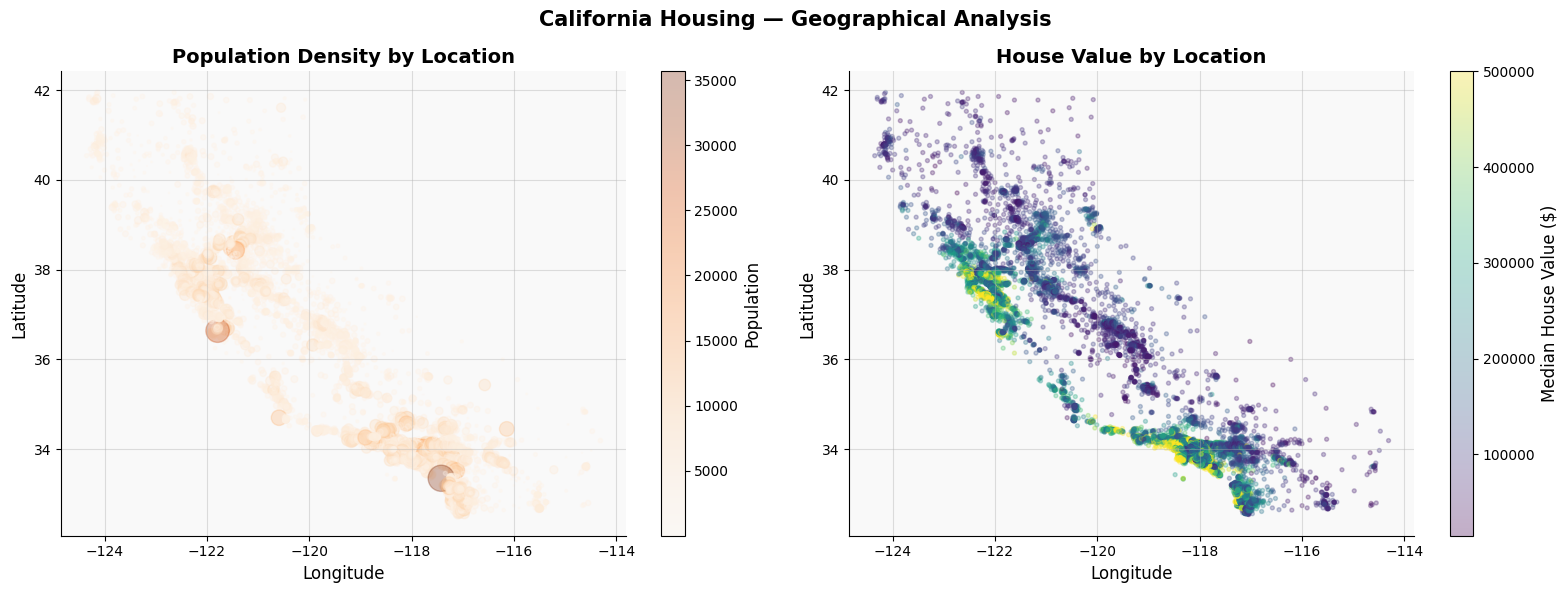

💡 Expensive clusters visible at SF Bay Area (~-122, 37) and LA (~-118, 34)
💡 Population density matches coastal urban areas perfectly


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Population density
sc1 = axes[0].scatter(df['longitude'], df['latitude'],
                      alpha=0.3, s=df['population']/100,
                      c=df['population'], cmap='Oranges')
plt.colorbar(sc1, ax=axes[0], label='Population')
axes[0].set_title('Population Density by Location')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Plot 2 — House value by location
sc2 = axes[1].scatter(df['longitude'], df['latitude'],
                      alpha=0.3, s=8,
                      c=df['median_house_value'], cmap=PALETTE)
plt.colorbar(sc2, ax=axes[1], label='Median House Value ($)')
axes[1].set_title('House Value by Location')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('California Housing — Geographical Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/geographical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Expensive clusters visible at SF Bay Area (~-122, 37) and LA (~-118, 34)')
print('💡 Population density matches coastal urban areas perfectly')

## 8. Ocean Proximity Analysis <a id='8-ocean'></a>

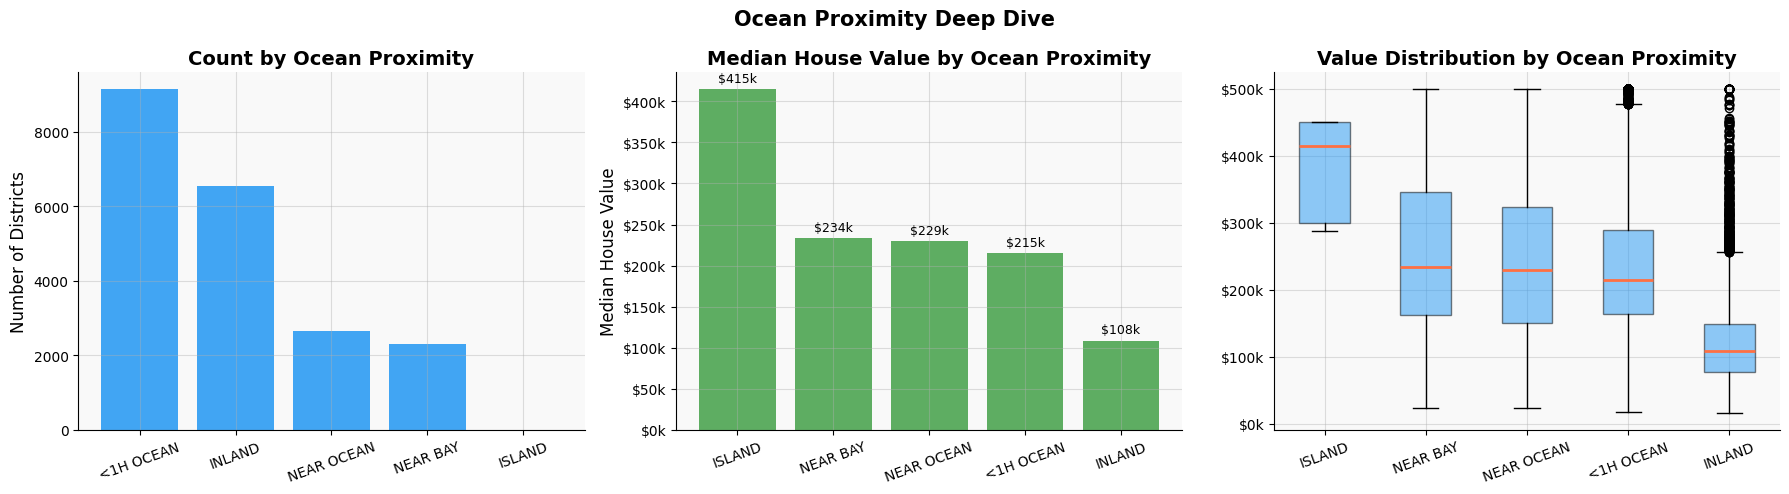


── Median House Value by Ocean Proximity ──


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

order = df.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False).index

# Count
count_data = df['ocean_proximity'].value_counts()
axes[0].bar(count_data.index, count_data.values, color=ACCENT, alpha=0.85)
axes[0].set_title('Count by Ocean Proximity')
axes[0].set_ylabel('Number of Districts')
axes[0].tick_params(axis='x', rotation=20)

# Median house value
median_vals = df.groupby('ocean_proximity')['median_house_value'].median().reindex(order)
bars = axes[1].bar(median_vals.index, median_vals.values, color=GREEN, alpha=0.85)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].bar_label(bars, fmt=lambda x: f'${x/1000:.0f}k', padding=3, fontsize=9)
axes[1].set_title('Median House Value by Ocean Proximity')
axes[1].set_ylabel('Median House Value')
axes[1].tick_params(axis='x', rotation=20)

# Box plot
data_by_prox = [df[df['ocean_proximity'] == cat]['median_house_value'].values for cat in order]
bp = axes[2].boxplot(data_by_prox, labels=order, patch_artist=True,
                     boxprops=dict(facecolor=ACCENT, alpha=0.5),
                     medianprops=dict(color=ORANGE, linewidth=2))
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[2].set_title('Value Distribution by Ocean Proximity')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Ocean Proximity Deep Dive', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/ocean_proximity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Median House Value by Ocean Proximity ──')
print(df.groupby('ocean_proximity')['median_house_value']
        .agg(['median','mean','count'])
        .sort_values('median', ascending=False)
        .style.format({'median':'${:,.0f}','mean':'${:,.0f}'}))

## 9. Feature Engineering Insights <a id='9-engineering'></a>

── Engineered Features Correlation with Target ──
  rooms_per_household           : +0.152  ████
  bedrooms_per_room             : -0.256  ███████
  population_per_household      : -0.024  


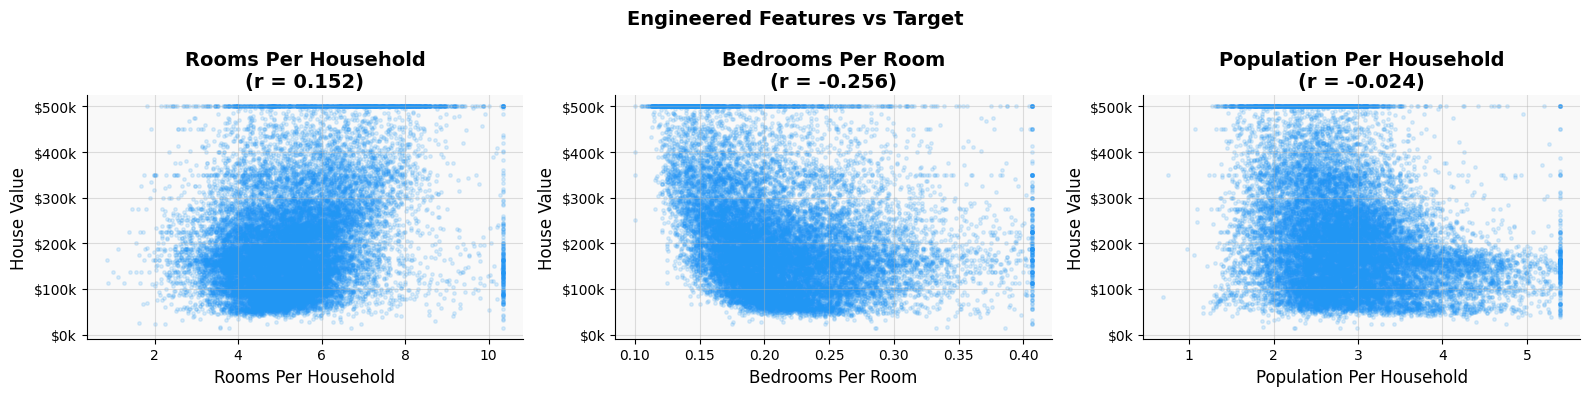


💡 bedrooms_per_room has STRONG negative correlation (-0.25)
   More bedrooms relative to total rooms = lower quality housing = lower value
💡 rooms_per_household positive correlation — bigger houses = higher value


In [14]:
# ── Create engineered features ────────────────────────────
df_eng = df.copy()
df_eng['rooms_per_household']      = df_eng['total_rooms']    / df_eng['households']
df_eng['bedrooms_per_room']        = df_eng['total_bedrooms'] / df_eng['total_rooms']
df_eng['population_per_household'] = df_eng['population']     / df_eng['households']

new_features = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']

# Correlation of new features with target
new_corr = df_eng[new_features + ['median_house_value']].corr()['median_house_value'].drop('median_house_value')

print('── Engineered Features Correlation with Target ──')
for feat, val in new_corr.items():
    bar = '█' * int(abs(val) * 30)
    direction = '+' if val > 0 else '-'
    print(f'  {feat:30s}: {direction}{abs(val):.3f}  {bar}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, feat in enumerate(new_features):
    axes[i].scatter(df_eng[feat].clip(upper=df_eng[feat].quantile(0.99)),
                    df_eng['median_house_value'],
                    alpha=0.15, s=6, color=ACCENT)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    axes[i].set_xlabel(feat.replace('_', ' ').title())
    axes[i].set_ylabel('House Value')
    axes[i].set_title(f'{feat.replace("_"," ").title()}\n(r = {new_corr[feat]:.3f})')

plt.suptitle('Engineered Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 bedrooms_per_room has STRONG negative correlation (-0.25)')
print('   More bedrooms relative to total rooms = lower quality housing = lower value')
print('💡 rooms_per_household positive correlation — bigger houses = higher value')

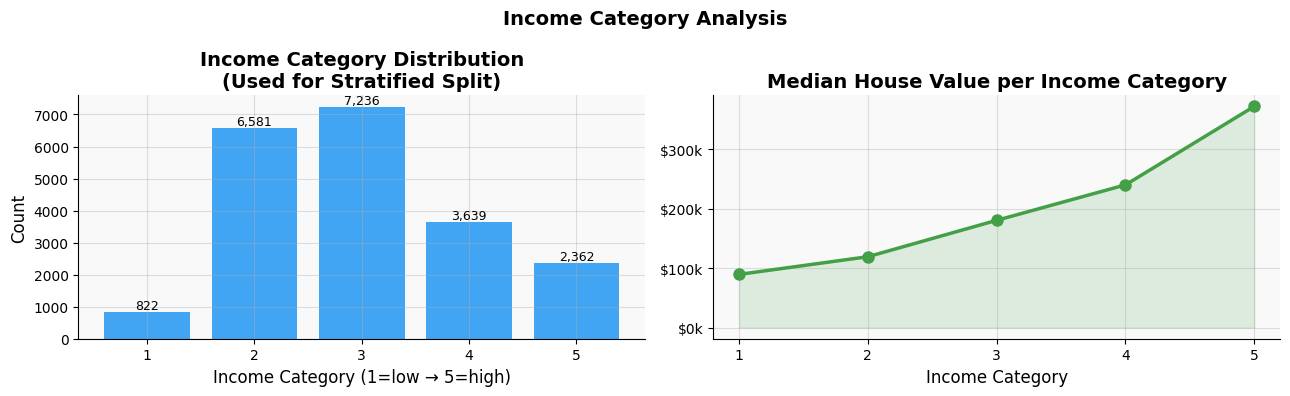

💡 Stratified split on income_cat ensures test set reflects the same income distribution as training set


In [15]:
# ── Income category analysis (used for stratified split) ──
df_eng['income_cat'] = pd.cut(df_eng['median_income'],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Income category distribution
count = df_eng['income_cat'].value_counts().sort_index()
axes[0].bar(count.index.astype(str), count.values, color=ACCENT, alpha=0.85)
axes[0].set_title('Income Category Distribution\n(Used for Stratified Split)')
axes[0].set_xlabel('Income Category (1=low → 5=high)')
axes[0].set_ylabel('Count')
for i, v in enumerate(count.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Median house value per income cat
inc_val = df_eng.groupby('income_cat')['median_house_value'].median()
axes[1].plot(inc_val.index.astype(str), inc_val.values,
             marker='o', linewidth=2.5, color=GREEN, markersize=8)
axes[1].fill_between(range(len(inc_val)), inc_val.values, alpha=0.15, color=GREEN)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_title('Median House Value per Income Category')
axes[1].set_xlabel('Income Category')
axes[1].set_xticks(range(len(inc_val)))
axes[1].set_xticklabels(inc_val.index.astype(str))

plt.suptitle('Income Category Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/income_category.png', dpi=150, bbox_inches='tight')
plt.show()

print('💡 Stratified split on income_cat ensures test set reflects the same income distribution as training set')

## 10. Key Findings Summary <a id='10-summary'></a>

In [16]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           EDA KEY FINDINGS — California Housing Dataset          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  📦 Dataset                                                      ║
║     • 20,640 rows × 10 columns                                   ║
║     • Only 1 column has missing values: total_bedrooms (207 rows)║
║     • Fix: SimpleImputer(strategy='median') in pipeline          ║
║                                                                  ║
║  🎯 Target Variable                                              ║
║     • Range: $14,999 – $500,001 (hard cap at $500,001)           ║
║     • Mean: ~$206,855   Median: ~$179,700                        ║
║     • Right-skewed distribution                                  ║
║                                                                  ║
║  🔗 Strongest Correlations with Target                           ║
║     • median_income          : +0.69  (strongest predictor)      ║
║     • latitude               : -0.14  (north = cheaper)          ║
║     • bedrooms_per_room (eng): -0.25  (quality indicator)        ║
║                                                                  ║
║  🌊 Ocean Proximity Impact                                       ║
║     • ISLAND        : most expensive (~$380k median)             ║
║     • NEAR BAY      : second (~$258k median)                     ║
║     • INLAND        : cheapest (~$124k median)                   ║
║                                                                  ║
║  🗺️  Geography                                                   ║
║     • SF Bay Area & LA show clear high-value clusters            ║
║     • Coastal areas consistently outperform inland               ║
║                                                                  ║
║  🔧 Feature Engineering Added                                    ║
║     • rooms_per_household      → positive signal                 ║
║     • bedrooms_per_room        → strong negative signal          ║
║     • population_per_household → crowding indicator              ║
║                                                                  ║
║  🤖 Model Results                                                ║
║     • Algorithm  : RandomForestRegressor (tuned)                 ║
║     • CV RMSE    : $48,713   (±$761 across 5 folds)              ║
║     • Train R²   : 0.9749                                        ║
║     • Tuning     : RandomizedSearchCV (20 iter, 5-fold)          ║
║     • Best Params: n_estimators=300, max_depth=40,               ║
║                    max_features=0.5, bootstrap=False             ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           EDA KEY FINDINGS — California Housing Dataset          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  📦 Dataset                                                      ║
║     • 20,640 rows × 10 columns                                   ║
║     • Only 1 column has missing values: total_bedrooms (207 rows)║
║     • Fix: SimpleImputer(strategy='median') in pipeline          ║
║                                                                  ║
║  🎯 Target Variable                                              ║
║     • Range: $14,999 – $500,001 (hard cap at $500,001)           ║
║     • Mean: ~$206,855   Median: ~$179,700                        ║
║     • Right-skewed distribution                                  ║
║                                                                  ║
║  🔗 Strongest Correlations with Ta